## **Analyzing the Shape and Quality Descriptors of parts of an object for a dataset with pixel-level part annotations**
original dataset directory = `/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v1/`

### Import modules, set paths and load datasets

In [42]:
import os
import cv2
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy
# from scipy.fft import fft

from mahotas.features import zernike_moments
from brisque import BRISQUE # NR-IQA
from pypiqe import piqe # NR-IQA

from skimage import img_as_ubyte
from skimage.measure import regionprops, label, shannon_entropy
from skimage.transform import resize
from skimage.color import rgb2gray
# from skimage.filters import laplace
# from sklearn.model_selection import train_test_split
from skvideo.measure import niqe # NR-IQA

import torch
# from torch import nn
from torchvision import transforms #, datasets
from torch.utils.data import DataLoader, Dataset
# from torch.optim.lr_scheduler import ReduceLROnPlateau
# import timm
import segmentation_models_pytorch as smp

# Patch imresize if missing
if not hasattr(scipy.misc, "imresize"):
    def imresize(arr, size, interp=None, mode=None):
        if isinstance(size, float):  # scale factor
            new_shape = (int(arr.shape[0] * size), int(arr.shape[1] * size))
        else:
            new_shape = size[:2]
        arr_resized = resize(arr, new_shape, order=3, mode="reflect", anti_aliasing=True)
        arr_resized = (arr_resized * 255).astype(np.uint8)
        return arr_resized
    scipy.misc.imresize = imresize

# Patch for deprecated NumPy aliases (for backward compatibility)
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'bool'):
    np.bool = bool

Load a dataset with pixel-level part annotations for performing shape analysis

In [43]:
# Hyperparameters
DEVICE_ID = 0
BATCH_SIZE = 128
IMAGE_SIZE = 320

# ---------------------------
# Torch Dataset
# ---------------------------
class PartWholeDataset(Dataset):
    def __init__(self, root, images_dir="images", masks_dir="masks", image_size=320):
        self.images_dir = os.path.join(root, images_dir)
        self.masks_dir = os.path.join(root, masks_dir)
        self.image_paths = sorted([os.path.join(self.images_dir, f) for f in os.listdir(self.images_dir)])
        self.image_size = image_size

        # transform for image
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            # transforms.Normalize(mean=[0.5016, 0.4647, 0.3782], std=[0.2738, 0.2654, 0.2885]) # Computed using the find_mean_and_sd_of_partwhole_dataset script
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        base = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(self.masks_dir, base + "_m.png")

        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)
        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)
        mask = torch.from_numpy(np.array(mask, dtype=np.int64))
        return img, mask
    
# Load the datasets
home_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v1/"
train_path = os.path.join(home_path, "train") # Path for the training data
# val_path = os.path.join(home_path, "val") # Path for validation data
# test_path = os.path.join(home_path, "test") # Path for testing data

train_dataset = PartWholeDataset(root=train_path, image_size=IMAGE_SIZE)
# val_dataset = PartWholeDataset(root=train_path, image_size=IMAGE_SIZE)
# test_dataset = PartWholeDataset(root=test_path, image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
# val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

num_classes = 4
print(f"Training with num_classes (including background) = {num_classes}")

Training with num_classes (including background) = 4


Plot sample masks from the dataset

In [44]:
def plot_all_submasks(mask):
    abdomen_mask = mask == 1
    head_mask = mask == 2
    thorax_mask = mask == 3
    plt.figure(figsize=(16,4))
    plt.subplot(1,4,1)
    plt.imshow(mask)
    plt.subplot(1,4,2)
    plt.imshow(head_mask)
    plt.subplot(1,4,3)
    plt.imshow(thorax_mask)
    plt.subplot(1,4,4)
    plt.imshow(abdomen_mask)
    plt.show()

def plot_image_and_submasks(image, mask):    
    if not isinstance(image, np.ndarray):
        # image_np = np.array(image).transpose(1, 2, 0) # Transform tensor to numpy image
        image_np = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    else:
        image_np = image
    abdomen_mask = mask == 1
    head_mask = mask == 2
    thorax_mask = mask == 3
    abdomen_cropped = np.zeros_like(image_np)
    head_cropped = np.zeros_like(image_np)
    thorax_cropped = np.zeros_like(image_np)
    abdomen_cropped[abdomen_mask==1] = image_np[abdomen_mask==1]    
    head_cropped[head_mask==1] = image_np[head_mask==1]    
    thorax_cropped[thorax_mask==1] = image_np[thorax_mask==1]
    plt.figure(figsize=(16,8))
    plt.subplot(2,4,1)
    plt.imshow(image_np)
    plt.subplot(2,4,2)
    plt.imshow(head_cropped)
    plt.subplot(2,4,3)
    plt.imshow(thorax_cropped)
    plt.subplot(2,4,4)
    plt.imshow(abdomen_cropped)
    plt.subplot(2,4,5)
    plt.imshow(mask)
    plt.subplot(2,4,6)
    plt.imshow(head_mask)
    plt.subplot(2,4,7)
    plt.imshow(thorax_mask)
    plt.subplot(2,4,8)
    plt.imshow(abdomen_mask)
    plt.show()

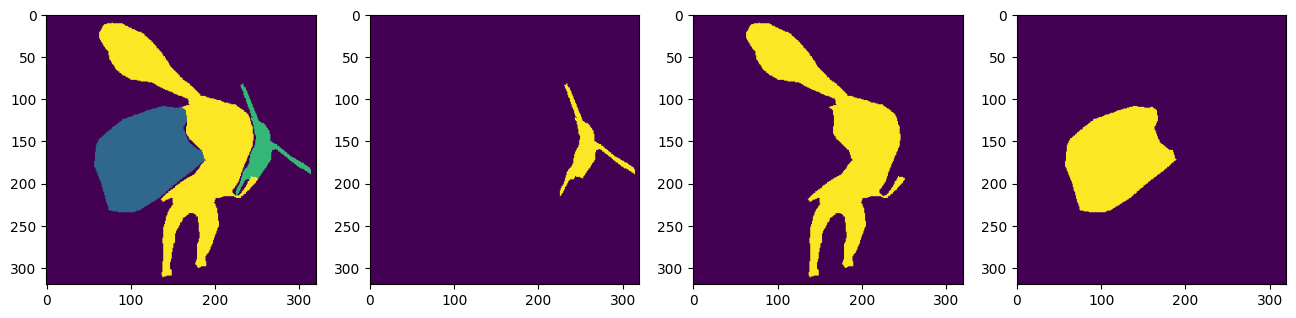

In [45]:
image, mask = train_dataset[8]
plot_all_submasks(mask)

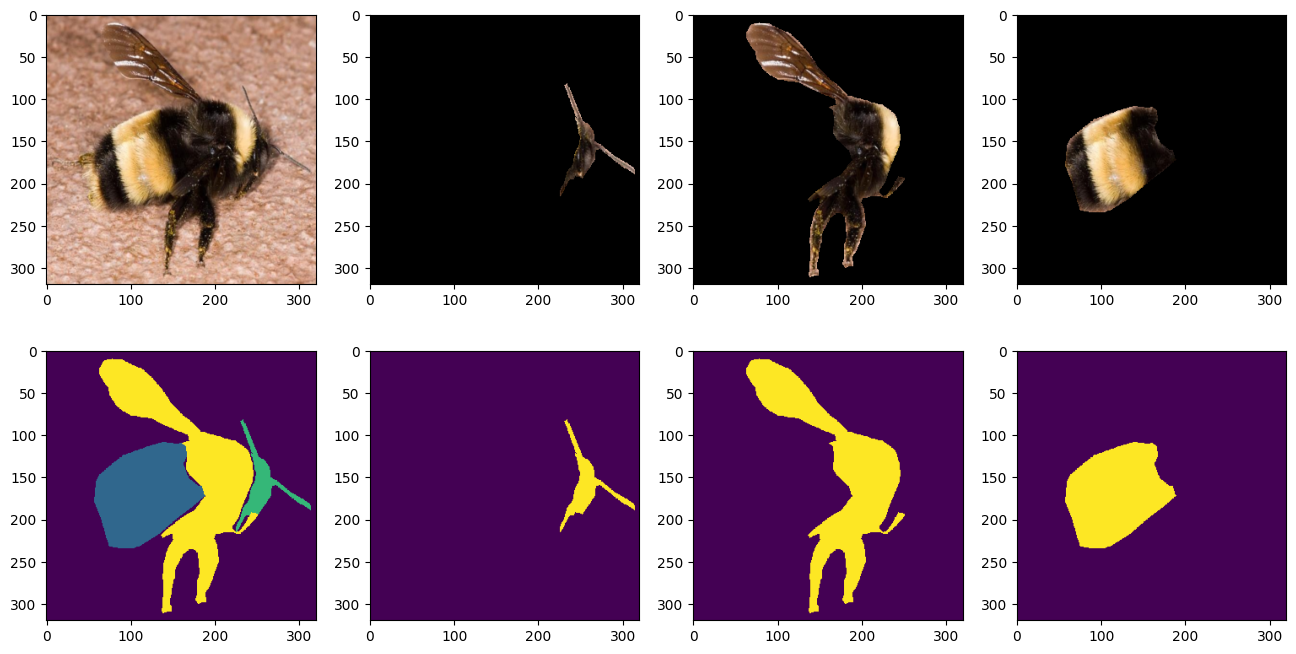

In [46]:
image, mask = train_dataset[8]
plot_image_and_submasks(image, mask)

### **Analyzing basic geometric features**: ("area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", "orientation", "circularity", "elongation", "compactness")

In [47]:
image, mask = train_dataset[8]
labeled = label(mask.numpy())
props = regionprops(labeled)
props

In [48]:
(label(mask.numpy()) == label(mask)).all()

True

In [49]:
abdomen_mask = mask == 1
labeled = label(abdomen_mask)
props = regionprops(labeled)
props, props[0].area, props[0]['area']

([<skimage.measure._regionprops.RegionProperties at 0x7f1cfc7c8ed0>],
 11049.0,
 11049.0)

In [50]:
def extract_base_features(mask):
    """Compute geometric, Zernike, Fourier, and texture shape descriptors from a binary mask."""
    
    features = ["area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", 
        "orientation", "circularity", "elongation", "compactness"]
    
    if mask is None or mask.sum() == 0:
        return {f: 0 for f in features}

    # --- Region properties ---
    # mask = mask.astype(np.uint8)
    labeled = label(mask)
    props = regionprops(labeled)
    if len(props) == 0:
        return {f: 0 for f in features}
    p = props[0]
    major_axis = p.major_axis_length
    minor_axis = p.minor_axis_length

    # ----- base shape features -----
    area = p.area
    perimeter = max(p.perimeter, 1e-6) # Ignoring too small perimeters
    aspect_ratio = major_axis / minor_axis if minor_axis > 0 else 0 # L_major / L_minor
    extent = p.extent
    solidity = p.solidity
    eccentricity = p.eccentricity
    orientation = p.orientation
    circularity = 4 * np.pi * area / (perimeter ** 2)
    elongation = 1 - (minor_axis / major_axis) if major_axis > 0 else 0
    # convexity = p.perimeter_convex / perimeter
    compactness = (perimeter ** 2) / (4 * np.pi * area + 1e-6)

    # ----- Assemble features -----
    features_d = {
        "area": area,
        "perimeter": perimeter,
        "aspect_ratio": aspect_ratio,
        "extent": extent,
        "solidity": solidity,
        "eccentricity": eccentricity,
        "orientation": orientation,
        "circularity": circularity,
        "elongation": elongation,
        "compactness": compactness
    }
    return features_d

In [51]:
image, mask = train_dataset[8]
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
base_features = {"head_features": extract_base_features(head_mask),
                 "thorax_features": extract_base_features(thorax_mask),
                 "abdomen_features": extract_base_features(abdomen_mask)}
base_features

{'head_features': {'area': 2037.0,
  'perimeter': 449.7594513539338,
  'aspect_ratio': 1.5604919042453267,
  'extent': 0.170803286936106,
  'solidity': 0.3207368918280586,
  'eccentricity': 0.7676881830611274,
  'orientation': 0.19300831110697933,
  'circularity': 0.12654363224017953,
  'elongation': 0.35917642553640006,
  'compactness': 7.902412648176055},
 'thorax_features': {'area': 15776.0,
  'perimeter': 1168.4722215136414,
  'aspect_ratio': 2.2736589479061213,
  'extent': 0.2778638861490771,
  'solidity': 0.4828895010713192,
  'eccentricity': 0.8980860928038442,
  'orientation': 0.3895603596058166,
  'circularity': 0.14520112364302357,
  'elongation': 0.5601802984036242,
  'compactness': 6.886999045912703},
 'abdomen_features': {'area': 11049.0,
  'perimeter': 435.88939366884495,
  'aspect_ratio': 1.3065490963698332,
  'extent': 0.6643217893217893,
  'solidity': 0.9523358041716945,
  'eccentricity': 0.6435845915808062,
  'orientation': -0.7955076297104589,
  'circularity': 0.7307

### **Analyzing Scale-Invariant Feature Transform (SIFT)**

In [52]:
def compute_sift_features(image, mask=None):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    if isinstance(mask, torch.Tensor):
        mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY) # converts image into uint8 and mask as input
    # gray_p = (gray * 255).astype(np.uint8) # Processed grayscale image
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 128), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def plot_sift_features(image, mask):
    if not isinstance(image, np.ndarray):
        image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    full_body = mask > 0
    abdomen_mask = mask == 1
    head_mask = mask == 2
    thorax_mask = mask == 3

    fig, axs = plt.subplots(1, 6, figsize=(24, 4))
    
    keypoints, descriptors = compute_sift_features(image, mask=None)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[0].set_title("SIFT features on full image")
    axs[0].imshow(img)

    keypoints, descriptors = compute_sift_features(image, mask=mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[1].set_title("SIFT features on the object")
    axs[1].imshow(img)

    keypoints, descriptors = compute_sift_features(image, mask=head_mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[2].set_title("SIFT features on head")
    axs[2].imshow(img)

    keypoints, descriptors = compute_sift_features(image, mask=thorax_mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[3].set_title("SIFT features on thorax")
    axs[3].imshow(img)

    keypoints, descriptors = compute_sift_features(image, mask=abdomen_mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[4].set_title("SIFT features on abdomen")
    axs[4].imshow(img)

    keypoints, descriptors = compute_sift_features(image, mask=full_body)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[5].set_title("SIFT features on the object (single mask)")
    axs[5].imshow(img)

In [53]:
image, mask = train_dataset[8]
full_body = mask > 0
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
body_kp, body_ds = compute_sift_features(image, mask)
head_kp, head_ds = compute_sift_features(image, head_mask)
thorax_kp, thorax_ds = compute_sift_features(image, thorax_mask)
abdomen_kp, abdomen_ds = compute_sift_features(image, abdomen_mask)
full_kp1, full_ds1 = compute_sift_features(image, full_body)
print("keypoints = ", head_kp, thorax_kp, abdomen_kp, body_kp)
print("descriptors = ", head_ds, thorax_ds, abdomen_ds, body_ds)

keypoints =  (< cv2.KeyPoint 0x7f1d0db4b030>, < cv2.KeyPoint 0x7f1cfc607ae0>, < cv2.KeyPoint 0x7f1d0525aa60>, < cv2.KeyPoint 0x7f1cf45bb900>, < cv2.KeyPoint 0x7f1cf45baf10>, < cv2.KeyPoint 0x7f1cf45baee0>, < cv2.KeyPoint 0x7f1cf45baf40>, < cv2.KeyPoint 0x7f1cf45bb9f0>, < cv2.KeyPoint 0x7f1cf45bbb40>, < cv2.KeyPoint 0x7f1cf45bbb10>, < cv2.KeyPoint 0x7f1cf45bbb70>, < cv2.KeyPoint 0x7f1cf45bbba0>, < cv2.KeyPoint 0x7f1cf45bbbd0>, < cv2.KeyPoint 0x7f1cf45bbc00>, < cv2.KeyPoint 0x7f1cf45b90b0>, < cv2.KeyPoint 0x7f1cf45b8f90>, < cv2.KeyPoint 0x7f1cf45ba670>, < cv2.KeyPoint 0x7f1cf45ba6a0>, < cv2.KeyPoint 0x7f1cf45ba6d0>, < cv2.KeyPoint 0x7f1cf45ba700>, < cv2.KeyPoint 0x7f1cf45ba730>, < cv2.KeyPoint 0x7f1cf45ba760>, < cv2.KeyPoint 0x7f1cf45ba790>, < cv2.KeyPoint 0x7f1cf45ba7c0>, < cv2.KeyPoint 0x7f1cf45ba7f0>, < cv2.KeyPoint 0x7f1cf45ba820>, < cv2.KeyPoint 0x7f1cf45ba850>, < cv2.KeyPoint 0x7f1cf45baac0>, < cv2.KeyPoint 0x7f1cf45baa30>, < cv2.KeyPoint 0x7f1cf45baa00>, < cv2.KeyPoint 0x7f1cf45ba

In [54]:
print("total keypoints and shape of descriptors for head, thorax, abdomen:\n",
      len(head_kp), len(thorax_kp), len(abdomen_kp), head_ds.shape, thorax_ds.shape, abdomen_ds.shape)
print("Maximum diameter of the head keypoints", max([k.size for k in head_kp]))
print("Maximum diameter of the thorax keypoints", max([k.size for k in thorax_kp]))
print("Maximum diameter of the abdomen keypoints", max([k.size for k in abdomen_kp]))
print("Mean diameter of the head keypoints", np.mean([k.size for k in head_kp]))
print("Mean diameter of the thorax keypoints", np.mean([k.size for k in thorax_kp]))
print("Mean diameter of the abdomen keypoints", np.mean([k.size for k in abdomen_kp]))
print("Mean descriptor of head and its shape", head_ds.mean(axis=0), head_ds.mean(axis=0).shape)
print("Mean descriptor of thorax and its shape", thorax_ds.mean(axis=0), thorax_ds.mean(axis=0).shape)
print("Mean descriptor of abdomen and its shape", abdomen_ds.mean(axis=0), abdomen_ds.mean(axis=0).shape)
print("Mean descriptor of fullbody and its shape", body_ds.mean(axis=0), body_ds.mean(axis=0).shape)
print("Mean descriptor of fullbody and its shape", full_ds1.mean(axis=0), full_ds1.mean(axis=0).shape)

total keypoints and shape of descriptors for head, thorax, abdomen:
 38 143 48 (38, 128) (143, 128) (48, 128)
Maximum diameter of the head keypoints 17.91472053527832
Maximum diameter of the thorax keypoints 79.73973083496094
Maximum diameter of the abdomen keypoints 38.26267623901367
Mean diameter of the head keypoints 3.3472453794981303
Mean diameter of the thorax keypoints 6.061794098440584
Mean diameter of the abdomen keypoints 6.421894277135531
Mean descriptor of head and its shape [ 17.947369   17.552631   18.842106   29.18421    26.447369   21.421053
  15.263158    6.8157897  52.210526   26.657894   10.552631   26.447369
  39.605263   20.236841   12.605263   17.         82.1579     31.81579
   6.631579   10.236842   12.210526   11.263158   11.131579   41.973682
  38.973682   25.657894    7.3157897   9.026316    6.8421054  12.
  11.131579   34.55263    32.473682   27.447369   13.263158   23.81579
  39.236843   21.31579    13.342105   15.394737   72.97369    25.973684
  11.421053 

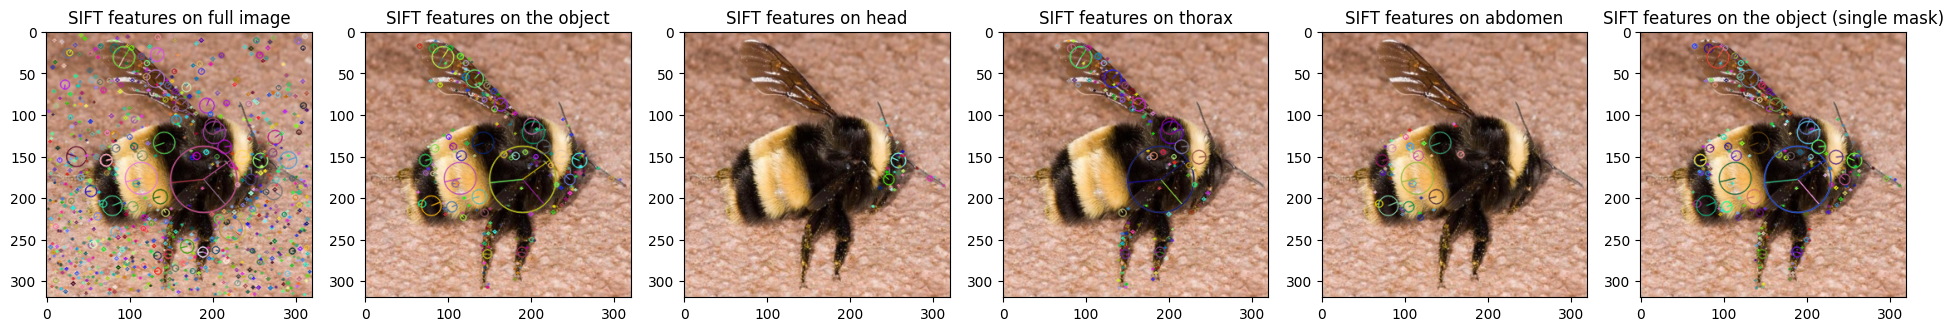

In [55]:
image, mask = train_dataset[8]
plot_sift_features(image, mask)

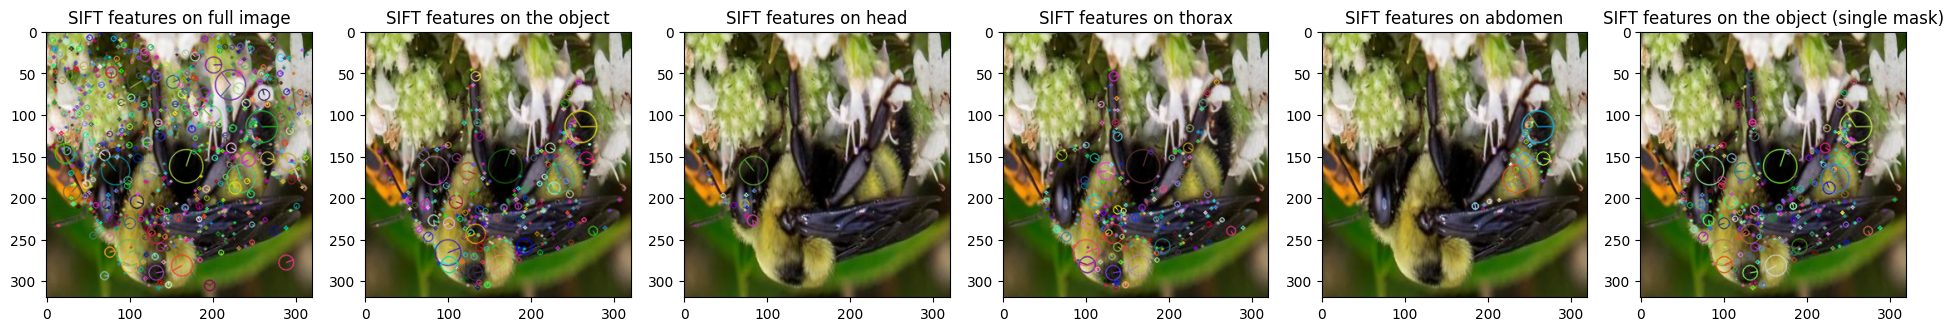

In [56]:
image, mask = train_dataset[90]
plot_sift_features(image, mask)

Based on the analysis, decided to take the number of keypoints and size (diameter) of the max keypoint, and the mean descriptors as the feature. Total features = 1 (num_keypoints) + 1 (max_size_keypoints) + mean_descriptors (128) = 130

### **Analyzing ORB: An efficient alternative to SIFT or SURF**

In [57]:
def compute_orb_features(image, mask=None):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    if isinstance(mask, torch.Tensor):
        mask = mask.numpy().astype(np.uint8)
    gray= cv2.cvtColor(img_as_ubyte(image), cv2.COLOR_RGB2GRAY)
    # gray_p = (gray * 255).astype(np.uint8) # Processed grayscale image
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(gray, mask)
    if descriptors is None:
        descriptors = np.full((0, 32), np.nan, dtype=np.float32)  # return empty array if no keypoints
    return keypoints, descriptors

def plot_orb_features(image, mask):
    if not isinstance(image, np.ndarray):
        image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    full_body = mask > 0
    abdomen_mask = mask == 1
    head_mask = mask == 2
    thorax_mask = mask == 3

    fig, axs = plt.subplots(1, 6, figsize=(24, 4)) # Creates a 2x2 grid of subplots
    
    keypoints, descriptors = compute_orb_features(image, mask=None)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[0].set_title("ORB features on full image")
    axs[0].imshow(img)

    keypoints, descriptors = compute_orb_features(image, mask=mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[1].set_title("ORB features on the object")
    axs[1].imshow(img)

    keypoints, descriptors = compute_orb_features(image, mask=head_mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[2].set_title("ORB features on head")
    axs[2].imshow(img)

    keypoints, descriptors = compute_orb_features(image, mask=thorax_mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[3].set_title("ORB features on thorax")
    axs[3].imshow(img)

    keypoints, descriptors = compute_orb_features(image, mask=abdomen_mask)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[4].set_title("ORB features on abdomen")
    axs[4].imshow(img)

    keypoints, descriptors = compute_orb_features(image, mask=full_body)
    img = cv2.drawKeypoints(img_as_ubyte(image), keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)    
    axs[5].set_title("ORB features on the object (single mask)")
    axs[5].imshow(img)


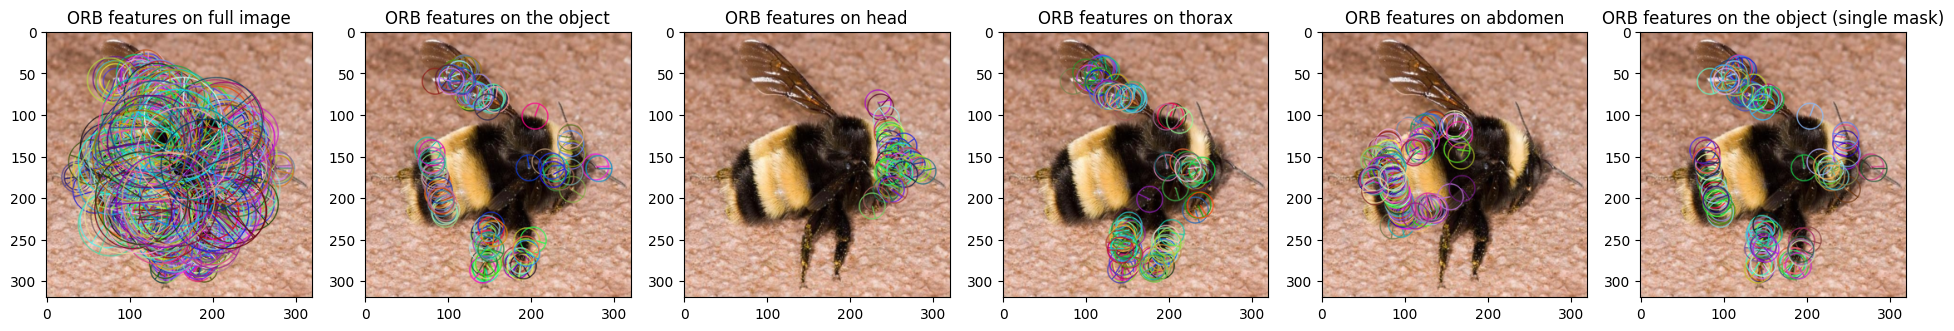

In [58]:
image, mask = train_dataset[8]
plot_orb_features(image, mask)

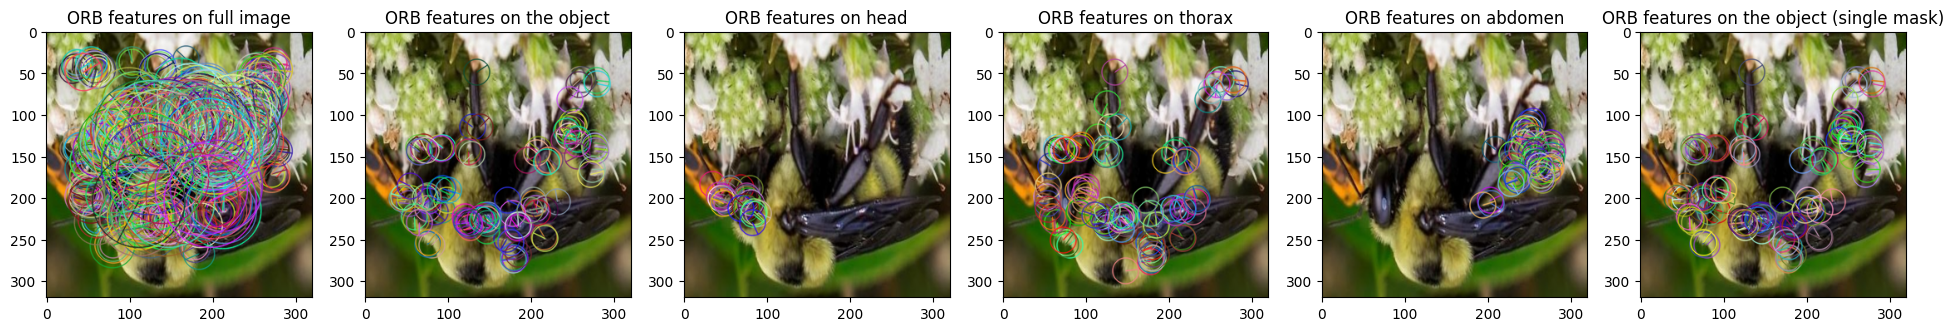

In [59]:
image, mask = train_dataset[90]
plot_orb_features(image, mask)

In [60]:
image, mask = train_dataset[8]
full_body = mask > 0
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
body_kp, body_ds = compute_orb_features(image, mask)
head_kp, head_ds = compute_orb_features(image, head_mask)
thorax_kp, thorax_ds = compute_orb_features(image, thorax_mask)
abdomen_kp, abdomen_ds = compute_orb_features(image, abdomen_mask)
body_kp2, body_ds2 = compute_orb_features(image, full_body)
print("keypoints = ", head_kp, thorax_kp, abdomen_kp, body_kp)
print("descriptors = ", head_ds, thorax_ds, abdomen_ds, body_ds)

keypoints =  (< cv2.KeyPoint 0x7f1cfc512e50>, < cv2.KeyPoint 0x7f1d0529b330>, < cv2.KeyPoint 0x7f1d05299d70>, < cv2.KeyPoint 0x7f1d0529b630>, < cv2.KeyPoint 0x7f1d0529b060>, < cv2.KeyPoint 0x7f1d0529b390>, < cv2.KeyPoint 0x7f1d05299da0>, < cv2.KeyPoint 0x7f1d052998c0>, < cv2.KeyPoint 0x7f1d0529b240>, < cv2.KeyPoint 0x7f1d0529b210>, < cv2.KeyPoint 0x7f1d0529afd0>, < cv2.KeyPoint 0x7f1d0529b5d0>, < cv2.KeyPoint 0x7f1d0529b6c0>, < cv2.KeyPoint 0x7f1d0529bd50>, < cv2.KeyPoint 0x7f1d0529bdb0>, < cv2.KeyPoint 0x7f1d0529bd80>, < cv2.KeyPoint 0x7f1d0529bde0>, < cv2.KeyPoint 0x7f1d0529be10>, < cv2.KeyPoint 0x7f1d0529bcf0>, < cv2.KeyPoint 0x7f1d0529bd20>, < cv2.KeyPoint 0x7f1d0529bea0>, < cv2.KeyPoint 0x7f1d0529be40>, < cv2.KeyPoint 0x7f1d0529b6f0>, < cv2.KeyPoint 0x7f1d0529b570>, < cv2.KeyPoint 0x7f1d052999b0>, < cv2.KeyPoint 0x7f1d05298e10>, < cv2.KeyPoint 0x7f1d05299890>, < cv2.KeyPoint 0x7f1d05299bf0>, < cv2.KeyPoint 0x7f1d05299c50>, < cv2.KeyPoint 0x7f1d0529a310>, < cv2.KeyPoint 0x7f1d05298

In [61]:
print("total keypoints and shape of descriptors for head, thorax, abdomen:\n",
      len(head_kp), len(thorax_kp), len(abdomen_kp), head_ds.shape, thorax_ds.shape, abdomen_ds.shape)
print("Maximum diameter of the head keypoints", max([k.size for k in head_kp]))
print("Maximum diameter of the thorax keypoints", max([k.size for k in thorax_kp]))
print("Maximum diameter of the abdomen keypoints", max([k.size for k in abdomen_kp]))
print("Mean diameter of the head keypoints", np.mean([k.size for k in head_kp]))
print("Mean diameter of the thorax keypoints", np.mean([k.size for k in thorax_kp]))
print("Mean diameter of the abdomen keypoints", np.mean([k.size for k in abdomen_kp]))
print("Mean descriptor of head and its shape", head_ds.mean(axis=0), head_ds.mean(axis=0).shape)
print("Mean descriptor of thorax and its shape", thorax_ds.mean(axis=0), thorax_ds.mean(axis=0).shape)
print("Mean descriptor of abdomen and its shape", abdomen_ds.mean(axis=0), abdomen_ds.mean(axis=0).shape)
print("Mean descriptor of full body and its shape", body_ds.mean(axis=0), body_ds.mean(axis=0).shape)
print("Mean descriptor of full body (single mask) and its shape", body_ds2.mean(axis=0), body_ds2.mean(axis=0).shape)

total keypoints and shape of descriptors for head, thorax, abdomen:
 47 109 109 (47, 32) (109, 32) (109, 32)
Maximum diameter of the head keypoints 31.0
Maximum diameter of the thorax keypoints 31.0
Maximum diameter of the abdomen keypoints 31.0
Mean diameter of the head keypoints 31.0
Mean diameter of the thorax keypoints 31.0
Mean diameter of the abdomen keypoints 31.0
Mean descriptor of head and its shape [ 87.44680851 160.40425532 178.95744681 181.65957447 173.87234043
 196.27659574 187.14893617 123.95744681 142.14893617 133.23404255
 137.42553191 129.82978723 145.14893617 167.12765957 144.04255319
 128.65957447 186.57446809 119.78723404 180.80851064 128.06382979
 147.21276596 140.44680851 134.68085106 216.9787234  133.29787234
 159.08510638 137.23404255 196.61702128 148.85106383 132.38297872
 159.36170213 192.53191489] (32,)
Mean descriptor of thorax and its shape [110.60550459 150.91743119 132.78899083 146.27522936 139.52293578
 145.59633028 160.37614679 164.53211009 137.31192661

The number of ord keypoints and mean descriptor will be taken for analysis. Total features = 1 (num_keypoints) + mean_descriptors (32) = 33

### **Hu moments (7 invariant shape descriptors)**

In [62]:
def compute_hu_moments(mask):
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    moments = cv2.moments(mask)
    hu = cv2.HuMoments(moments).flatten()
    hu = np.log(np.abs(hu) + 1e-12) # log-scale for stability
    return hu

In [63]:
image, mask = train_dataset[8]
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
full_mask = mask > 0

# ------- Hu moments (7 invariant shape descriptors) ---------
compute_hu_moments(mask), compute_hu_moments(full_mask)

(array([ -2.13763108,  -5.96195343,  -7.3203465 ,  -9.07635465,
        -17.98234034, -12.79476094, -17.41375155]),
 array([ -1.47899573,  -5.84286787,  -5.75381737,  -7.95124203,
        -14.82194928, -10.88292436, -16.46995529]))

**IMPORTANT**: must use the correct full_mask for computing hu moments

In [64]:
compute_hu_moments(head_mask), compute_hu_moments(thorax_mask), compute_hu_moments(abdomen_mask), compute_hu_moments(full_mask)

(array([-0.65940544, -3.0644055 , -1.52563103, -4.39833066, -7.52715127,
        -5.9442637 , -7.99020102]),
 array([-0.70360026, -2.19083999, -2.5542491 , -4.35845064, -9.57186448,
        -8.31542247, -7.82991351]),
 array([ -1.77669395,  -6.23837173, -10.05137336, -13.09184399,
        -25.61929701, -16.44301673, -24.66913543]),
 array([ -1.47899573,  -5.84286787,  -5.75381737,  -7.95124203,
        -14.82194928, -10.88292436, -16.46995529]))

### **Zernike moments**

In [65]:
def compute_zernike_moments(mask, degree=8):
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    radius = min(mask.shape) // 2
    mask_norm = mask / mask.max() if mask.max() > 0 else mask
    zern = zernike_moments(mask_norm, radius=radius, degree=degree)
    return zern

In [66]:
image, mask = train_dataset[8]
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
full_mask = mask > 0

# Compute zernike moments
print("Zernike moments and its shape for head, thorax, abdomen and full body:")
zern_h = compute_zernike_moments(head_mask)
zern_t = compute_zernike_moments(thorax_mask)
zern_a = compute_zernike_moments(abdomen_mask)
zern_b = compute_zernike_moments(full_mask)
print(f"Shape of zernike moments with maximum order of 8 (degrees), head: {zern_h.shape}, thorax: {zern_t.shape}, abdomen: {zern_a.shape}, full_body: {zern_b.shape}")
zern_h, zern_t, zern_a, zern_b

Zernike moments and its shape for head, thorax, abdomen and full body:
Shape of zernike moments with maximum order of 8 (degrees), head: (25,), thorax: (25,), abdomen: (25,), full_body: (25,)


(array([3.18309886e-01, 4.16503804e-16, 8.76338028e-01, 1.64170547e-02,
        9.50763720e-03, 1.33275446e-02, 1.23813870e+00, 6.83569504e-02,
        1.41494677e-03, 4.52687627e-02, 6.66381234e-02, 2.30571878e-03,
        1.37854437e+00, 1.47125297e-01, 6.93729331e-03, 1.02464979e-03,
        1.08012586e-01, 1.71929637e-01, 1.48127810e-02, 3.06302885e-04,
        1.35896277e+00, 2.29922239e-01, 1.66381939e-02, 7.32082896e-03,
        2.69675692e-04]),
 array([0.31830989, 0.00462168, 0.39147985, 0.18959133, 0.20159301,
        0.15694428, 0.19601705, 0.21941753, 0.09137318, 0.34012291,
        0.13845305, 0.16832037, 0.02107992, 0.09638438, 0.13932078,
        0.08521815, 0.31635345, 0.03841434, 0.18768586, 0.11386711,
        0.13681994, 0.03034112, 0.13826413, 0.06405231, 0.11275858]),
 array([3.18309886e-01, 8.92940397e-16, 8.15461199e-01, 1.82141614e-02,
        1.55524201e-03, 2.37086395e-03, 9.66212439e-01, 7.31363821e-02,
        2.67166924e-03, 7.20175705e-03, 1.15488827e-02, 

### **Fourier Descriptors**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


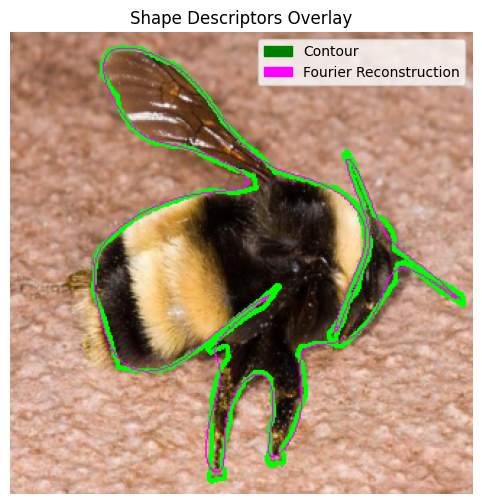

Shape of fourier descriptors, head: (20,), thorax: (20,), abdomen: (20,), body: (20,)


(array([8.53260444e-16, 1.00000000e+00, 2.18932140e+00, 2.40016542e-01,
        1.50963500e-01, 2.46705730e-01, 7.21778049e-02, 1.14291428e-01,
        8.42632918e-02, 3.54910988e-02, 3.55220032e-02, 4.06051117e-02,
        3.92511982e-02, 4.18956928e-02, 1.44343698e-02, 2.12551073e-02,
        3.31470378e-03, 2.31714627e-02, 4.65451522e-03, 1.38889369e-02]),
 array([4.08677387e-16, 1.00000000e+00, 6.18749304e-01, 2.16478458e-01,
        5.50121460e-02, 1.02072873e-01, 2.07109792e-01, 9.93410049e-02,
        2.73954833e-02, 4.08935864e-02, 3.10429301e-02, 5.75318100e-02,
        1.27457259e-02, 1.33684051e-02, 1.07347878e-02, 1.95760203e-02,
        3.09653049e-03, 1.41650962e-02, 2.29199653e-02, 1.21215959e-02]))

In [67]:
# *** Updated fourier descriptors (Dec 4, 2025)
def compute_fourier_descriptors(mask, image=None, fourier_harmonics=20, visualize=False):
    if not isinstance(mask, np.ndarray): # Ensure proper mask format
        mask = mask.numpy().astype(np.uint8)
    # --- 2. Find largest contour (object part) ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    cnt = max(contours, key=cv2.contourArea)
    if len(cnt) < 3:
        # Too few points for Fourier transform
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)
    
    # Translation invariance: center contour
    complex_contour = cnt[:,0,0] + 1j * cnt[:,0,1]
    fd = np.fft.fft(complex_contour)
    
    if visualize: # ** IMPORTANT: Visualization uses raw contour (so you can see the real shape), descriptors are centered.
        # Convert image if needed
        H, W = mask.shape
        if image is not None:
            if isinstance(image, torch.Tensor):
                image = image.detach().cpu().numpy().transpose(1, 2, 0)
            elif isinstance(image, Image.Image):
                image = np.array(image.convert('RGB'))
            elif image.dtype != np.uint8:  # NumPy float → uint8
                image = (image*255).astype(np.uint8)
            img_draw = image.copy()
        else:
            img_draw = np.zeros((H, W, 3), dtype=np.uint8)
        cv2.drawContours(img_draw, [cnt.astype(np.int32)], -1, (0, 255, 0), 2)

        fd_recon = fd.copy()
        keep = fourier_harmonics
        if 2 * keep < len(fd_recon):
            fd_recon[keep:-keep] = 0 # Safe zeroing
        else:
            fd_recon[keep:] = 0
        recon = np.fft.ifft(fd_recon)
        pts = np.column_stack((recon.real, recon.imag)).astype(np.int32)

        for i in range(len(pts)):
            cv2.line(img_draw, tuple(pts[i]), tuple(pts[(i + 1) % len(pts)]), (255, 0, 255), 1)
        plt.figure(figsize=(16, 6))
        plt.imshow(img_draw)
        plt.axis('off')
        plt.title("Shape Descriptors Overlay")
        plt.legend(
            handles=[
                Patch(facecolor='green', edgecolor='green'),
                Patch(facecolor='magenta', edgecolor='magenta')
            ],
            labels=["Contour", "Fourier Reconstruction"],
            loc='upper right'
        )
        plt.show()
    
    cnt_centered = complex_contour - np.mean(complex_contour)
    fd = np.fft.fft(cnt_centered)
    if len(fd) < 2 or np.abs(fd[1]) == 0:
        return np.full(fourier_harmonics, np.nan, dtype=np.float32)

    # Scale invariance: divide by first descriptor magnitude
    fd = fd / np.abs(fd[1])

    # Rotation invariance: use only magnitudes
    fd_normalized = np.abs(fd)

    # Keep only first N harmonics
    fd_truncated = fd_normalized[:fourier_harmonics]
    if len(fd_truncated) < fourier_harmonics:
        fd_truncated = np.concatenate([fd_truncated, np.full((fourier_harmonics - len(fd_truncated)), np.nan)])
    return fd_truncated

image, mask = train_dataset[8]
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
full_mask = mask > 0

body_f = compute_fourier_descriptors(mask=full_mask, image=image, visualize=True)
head_f = compute_fourier_descriptors(head_mask)
thorax_f = compute_fourier_descriptors(thorax_mask)
abdomen_f = compute_fourier_descriptors(abdomen_mask)
print(f"Shape of fourier descriptors, head: {head_f.shape}, thorax: {thorax_f.shape}, abdomen: {abdomen_f.shape}, body: {body_f.shape}")
head_f, thorax_f

### **Total Shape Descriptors**

In [68]:
def extract_shape_features(image, mask):
    # Compute base features
    features = extract_base_features(mask)

    # Compute sift features
    sift_kp, sift_ds = compute_sift_features(image, mask)
    sift_sizes = [k.size for k in sift_kp]
    if sift_ds.shape[0] > 0:
        sift_mean_ds = np.nanmean(sift_ds, axis=0)
    else:
        sift_mean_ds = np.full(128, np.nan)
    sift_dict = {f'sift_ds{i+1}': sift_mean_ds[i] for i in range(len(sift_mean_ds))}
    sift_dict['sift_kp_n'] = len(sift_kp)
    sift_dict['sift_kp_size'] = np.max(sift_sizes) if sift_sizes else 0

    # Compute orb features
    orb_kp, orb_ds = compute_orb_features(image, mask)
    if orb_ds.shape[0] > 0:
        orb_mean_ds = np.nanmean(orb_ds, axis=0)
    else:
        orb_mean_ds = np.full(32, np.nan)
    orb_dict = {f'orb_ds{i+1}': orb_mean_ds[i] for i in range(len(orb_mean_ds))}
    orb_dict['orb_kp_n'] = len(orb_kp)

    # Compute hu moments
    hu_moments = compute_hu_moments(mask)
    hu_dict = {f"hu{i+1}": hu_moments[i] for i in range(len(hu_moments))}

    # Compute Zernike moments
    zern_moments = compute_zernike_moments(mask, degree=8)
    zern_dict = {f"zernike_{i+1}": zern_moments[i] for i in range(len(zern_moments))}

    # Compute fourier descriptors
    fourier_ds = compute_fourier_descriptors(mask, fourier_harmonics=20)
    fourier_dict = {f"fourier_{i+1}": fourier_ds[i] for i in range(len(fourier_ds))}

    features.update(sift_dict)
    features.update(orb_dict)
    features.update(hu_dict)
    features.update(zern_dict)
    features.update(fourier_dict)
    converted = {k: np.float32(v) for k, v in features.items()}
    return converted

In [69]:
image, mask = train_dataset[8]
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
full_mask = mask > 0

print("All shape descriptors for head mask:")
head_feats = extract_shape_features(image, head_mask)
print(head_feats)
head_df = pd.DataFrame.from_dict([head_feats])
head_df

All shape descriptors for head mask:
{'area': 2037.0, 'perimeter': 449.75946, 'aspect_ratio': 1.5604919, 'extent': 0.1708033, 'solidity': 0.32073689, 'eccentricity': 0.76768816, 'orientation': 0.19300832, 'circularity': 0.12654363, 'elongation': 0.35917643, 'compactness': 7.9024124, 'sift_ds1': 17.947369, 'sift_ds2': 17.552631, 'sift_ds3': 18.842106, 'sift_ds4': 29.18421, 'sift_ds5': 26.447369, 'sift_ds6': 21.421053, 'sift_ds7': 15.263158, 'sift_ds8': 6.8157897, 'sift_ds9': 52.210526, 'sift_ds10': 26.657894, 'sift_ds11': 10.552631, 'sift_ds12': 26.447369, 'sift_ds13': 39.605263, 'sift_ds14': 20.236841, 'sift_ds15': 12.605263, 'sift_ds16': 17.0, 'sift_ds17': 82.1579, 'sift_ds18': 31.81579, 'sift_ds19': 6.631579, 'sift_ds20': 10.236842, 'sift_ds21': 12.210526, 'sift_ds22': 11.263158, 'sift_ds23': 11.131579, 'sift_ds24': 41.973682, 'sift_ds25': 38.973682, 'sift_ds26': 25.657894, 'sift_ds27': 7.3157897, 'sift_ds28': 9.026316, 'sift_ds29': 6.8421054, 'sift_ds30': 12.0, 'sift_ds31': 11.13157

,area,perimeter,aspect_ratio,extent,solidity,eccentricity,orientation,circularity,elongation,compactness,...,fourier_11,fourier_12,fourier_13,fourier_14,fourier_15,fourier_16,fourier_17,fourier_18,fourier_19,fourier_20
0,2037.0,449.75946,1.560492,0.170803,0.320737,0.767688,0.193008,0.126544,0.359176,7.902412,...,0.035522,0.040605,0.039251,0.041896,0.014434,0.021255,0.003315,0.023171,0.004655,0.013889


In [70]:
thorax_feats = extract_shape_features(image, thorax_mask)
print(thorax_feats)
thorax_df = pd.DataFrame.from_dict([thorax_feats])
thorax_df

{'area': 15776.0, 'perimeter': 1168.4722, 'aspect_ratio': 2.273659, 'extent': 0.2778639, 'solidity': 0.4828895, 'eccentricity': 0.8980861, 'orientation': 0.38956037, 'circularity': 0.14520112, 'elongation': 0.5601803, 'compactness': 6.886999, 'sift_ds1': 21.006992, 'sift_ds2': 17.692308, 'sift_ds3': 15.566434, 'sift_ds4': 19.972029, 'sift_ds5': 26.692308, 'sift_ds6': 15.195805, 'sift_ds7': 9.538462, 'sift_ds8': 10.307693, 'sift_ds9': 64.86014, 'sift_ds10': 34.6014, 'sift_ds11': 19.342657, 'sift_ds12': 18.433567, 'sift_ds13': 22.342657, 'sift_ds14': 12.496504, 'sift_ds15': 11.020979, 'sift_ds16': 25.643356, 'sift_ds17': 78.405594, 'sift_ds18': 30.818182, 'sift_ds19': 12.993007, 'sift_ds20': 13.762238, 'sift_ds21': 22.804195, 'sift_ds22': 14.818182, 'sift_ds23': 14.230769, 'sift_ds24': 39.237762, 'sift_ds25': 35.18182, 'sift_ds26': 13.195805, 'sift_ds27': 9.489511, 'sift_ds28': 11.181818, 'sift_ds29': 18.524475, 'sift_ds30': 15.895105, 'sift_ds31': 15.188811, 'sift_ds32': 26.874126, 'sif

,area,perimeter,aspect_ratio,extent,solidity,eccentricity,orientation,circularity,elongation,compactness,...,fourier_11,fourier_12,fourier_13,fourier_14,fourier_15,fourier_16,fourier_17,fourier_18,fourier_19,fourier_20
0,15776.0,1168.472168,2.273659,0.277864,0.48289,0.898086,0.38956,0.145201,0.56018,6.886999,...,0.031043,0.057532,0.012746,0.013368,0.010735,0.019576,0.003097,0.014165,0.02292,0.012122


In [71]:
abdomen_feats = extract_shape_features(image, abdomen_mask)
print(abdomen_feats)
abdomen_df = pd.DataFrame([abdomen_feats])
abdomen_df

{'area': 11049.0, 'perimeter': 435.8894, 'aspect_ratio': 1.3065491, 'extent': 0.6643218, 'solidity': 0.9523358, 'eccentricity': 0.6435846, 'orientation': -0.7955076, 'circularity': 0.7307692, 'elongation': 0.23462501, 'compactness': 1.3684211, 'sift_ds1': 20.645834, 'sift_ds2': 18.541666, 'sift_ds3': 12.333333, 'sift_ds4': 19.041666, 'sift_ds5': 19.375, 'sift_ds6': 8.541667, 'sift_ds7': 8.875, 'sift_ds8': 12.229167, 'sift_ds9': 73.020836, 'sift_ds10': 39.395832, 'sift_ds11': 14.479167, 'sift_ds12': 12.229167, 'sift_ds13': 7.5, 'sift_ds14': 3.9791667, 'sift_ds15': 9.4375, 'sift_ds16': 29.0625, 'sift_ds17': 90.5, 'sift_ds18': 34.75, 'sift_ds19': 11.854167, 'sift_ds20': 6.6458335, 'sift_ds21': 9.666667, 'sift_ds22': 9.354167, 'sift_ds23': 14.8125, 'sift_ds24': 43.395832, 'sift_ds25': 41.208332, 'sift_ds26': 16.270834, 'sift_ds27': 7.6458335, 'sift_ds28': 5.0416665, 'sift_ds29': 20.270834, 'sift_ds30': 18.375, 'sift_ds31': 17.354166, 'sift_ds32': 32.395832, 'sift_ds33': 27.416666, 'sift_ds

,area,perimeter,aspect_ratio,extent,solidity,eccentricity,orientation,circularity,elongation,compactness,...,fourier_11,fourier_12,fourier_13,fourier_14,fourier_15,fourier_16,fourier_17,fourier_18,fourier_19,fourier_20
0,11049.0,435.889404,1.306549,0.664322,0.952336,0.643585,-0.795508,0.730769,0.234625,1.368421,...,0.002589,0.013874,0.017774,0.017431,0.004998,0.011107,0.005487,0.005169,0.009778,0.016588


In [72]:
body_feats = extract_shape_features(image, full_mask)
print(body_feats)
body_df = pd.DataFrame([body_feats])
body_df

{'area': 28862.0, 'perimeter': 1961.0084, 'aspect_ratio': 1.2724007, 'extent': 0.3718659, 'solidity': 0.5907928, 'eccentricity': 0.61833334, 'orientation': 0.5122966, 'circularity': 0.09431427, 'elongation': 0.21408406, 'compactness': 10.60285, 'sift_ds1': 20.42358, 'sift_ds2': 17.847162, 'sift_ds3': 15.432315, 'sift_ds4': 21.305677, 'sift_ds5': 25.117905, 'sift_ds6': 14.834061, 'sift_ds7': 10.349345, 'sift_ds8': 10.131004, 'sift_ds9': 64.47162, 'sift_ds10': 34.288208, 'sift_ds11': 16.86463, 'sift_ds12': 18.462883, 'sift_ds13': 22.09607, 'sift_ds14': 11.995633, 'sift_ds15': 10.951965, 'sift_ds16': 24.925764, 'sift_ds17': 81.56332, 'sift_ds18': 31.80786, 'sift_ds19': 11.69869, 'sift_ds20': 11.68559, 'sift_ds21': 18.292576, 'sift_ds22': 13.08297, 'sift_ds23': 13.838428, 'sift_ds24': 40.56332, 'sift_ds25': 37.074234, 'sift_ds26': 15.908297, 'sift_ds27': 8.742358, 'sift_ds28': 9.537118, 'sift_ds29': 16.951965, 'sift_ds30': 15.7685585, 'sift_ds31': 14.969432, 'sift_ds32': 29.305677, 'sift_d

,area,perimeter,aspect_ratio,extent,solidity,eccentricity,orientation,circularity,elongation,compactness,...,fourier_11,fourier_12,fourier_13,fourier_14,fourier_15,fourier_16,fourier_17,fourier_18,fourier_19,fourier_20
0,28862.0,1961.008423,1.272401,0.371866,0.590793,0.618333,0.512297,0.094314,0.214084,10.60285,...,0.602772,0.441271,0.30686,0.163126,0.127334,0.107288,0.088249,0.055006,0.262679,0.026459


**Total number of shape descriptors**: For each mask, we have 10 base features ("area", "perimeter", "aspect_ratio", "extent", "solidity", "eccentricity", "orientation", "circularity", "elongation", "compactness"), 130 sift features (sift_kps, sift_kp_size and 128 descriptors), 33 orb features (orb_kps and 32 descriptors), 7 hu moments, 25 zernike moments (for order 8), 20 fourier descriptors. Therefore, total number of shape descriptors = 10+130+33+7+25+30 = 225 shape descriptors

### Visualization

In [73]:
def bgr_to_rgb_normalized(bgr):
    # Convert BGR 0-255 to RGB 0-1
    b, g, r = bgr
    return (r/255, g/255, b/255)

def visualize_shape_descriptors(mask, image=None, zernike_degree=8, fourier_harmonics=20):
    """
    Visualize shape descriptors for a given binary mask and optionally overlay on the image,
    with legends for contours, convex hull, fitted ellipse, bounding box, and Fourier reconstruction.
    
    Args:
        mask (np.array): binary mask of shape (H, W), 1 = object, 0 = background
        image (np.array): optional RGB image to overlay features (H, W, 3), dtype=uint8
        zernike_degree (int): maximum degree for Zernike moments
        fourier_harmonics (int): number of Fourier harmonics to keep in reconstruction
    """
    H, W = mask.shape
    mask_uint8 = (mask > 0).astype(np.uint8)
    
    # Prepare image to draw
    if image is not None:
        img_draw = image.copy()
    else:
        img_draw = np.zeros((H, W, 3), dtype=np.uint8)
    
    # --- Contour and Convex Hull ---
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        raise ValueError("No contour found in mask.")
    
    cnt = max(contours, key=cv2.contourArea)
    
    # Ensure correct shape
    if cnt.dtype != np.int32:
        cnt = cnt.astype(np.int32)
    if len(cnt.shape) == 2:
        cnt = cnt[:, np.newaxis, :]
    
    cv2.drawContours(img_draw, [cnt], -1, (0,255,0), 2)  # contour in green
    hull = cv2.convexHull(cnt)
    cv2.drawContours(img_draw, [hull], -1, (255,0,0), 2)  # convex hull in blue
    
    # --- Fitted ellipse ---
    if cnt.shape[0] >= 5:
        (x, y), (MA, ma), angle = cv2.fitEllipse(cnt)
        cv2.ellipse(img_draw,
                    center=(int(x), int(y)),
                    axes=(int(MA/2), int(ma/2)),
                    angle=angle,
                    startAngle=0, endAngle=360,
                    color=(0,255,255),
                    thickness=2)
    
    # --- Aspect ratio bounding box ---
    x_min, y_min, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_draw, (x_min, y_min), (x_min+w, y_min+h), (255,255,0), 2)
    
    # --- Fourier reconstruction ---
    complex_contour = cnt[:,0,0] + 1j * cnt[:,0,1]
    fd = np.fft.fft(complex_contour)
    fd[fourier_harmonics:-fourier_harmonics] = 0
    reconstructed = np.fft.ifft(fd)
    reconstructed_pts = np.stack([reconstructed.real, reconstructed.imag], axis=-1).astype(np.int32)
    for i in range(len(reconstructed_pts)):
        pt1 = tuple(reconstructed_pts[i % len(reconstructed_pts)])
        pt2 = tuple(reconstructed_pts[(i+1) % len(reconstructed_pts)])
        cv2.line(img_draw, pt1, pt2, (255,0,255), 2)
    
    # --- Zernike moments heatmap ---
    radius = min(H, W)//2
    mask_norm = mask_uint8.astype(np.float32)
    zernike_vec = zernike_moments(mask_norm, radius, degree=zernike_degree)
    zernike_mag = np.abs(zernike_vec)
    
    # --- Plotting ---
    plt.figure(figsize=(16,6))
    
    # Left: shape descriptors overlay
    plt.subplot(1,2,1)
    plt.imshow(img_draw)
    plt.axis('off')
    plt.title("Shape Descriptors Overlay")
    
    # Add legend manually
    legend_elements = [
    Patch(facecolor=bgr_to_rgb_normalized((0,255,0)), label='Contour'),
    Patch(facecolor=bgr_to_rgb_normalized((0,0,255)), label='Convex Hull'),
    Patch(facecolor=bgr_to_rgb_normalized((255,255,0)), label='Fitted Ellipse'),
    Patch(facecolor=bgr_to_rgb_normalized((0,255,255)), label='Bounding Box (Aspect Ratio)'),
    Patch(facecolor=bgr_to_rgb_normalized((255,0,255)), label='Fourier Reconstruction')
]
    plt.legend(handles=legend_elements, loc='upper right')
    
    # Right: Zernike heatmap
    plt.subplot(1,2,2)
    plt.imshow(zernike_mag.reshape(1, -1), aspect='auto', cmap='viridis')
    plt.title("Zernike Moments Magnitude Heatmap")
    plt.xlabel("Moment index")
    plt.ylabel("Magnitude")
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()

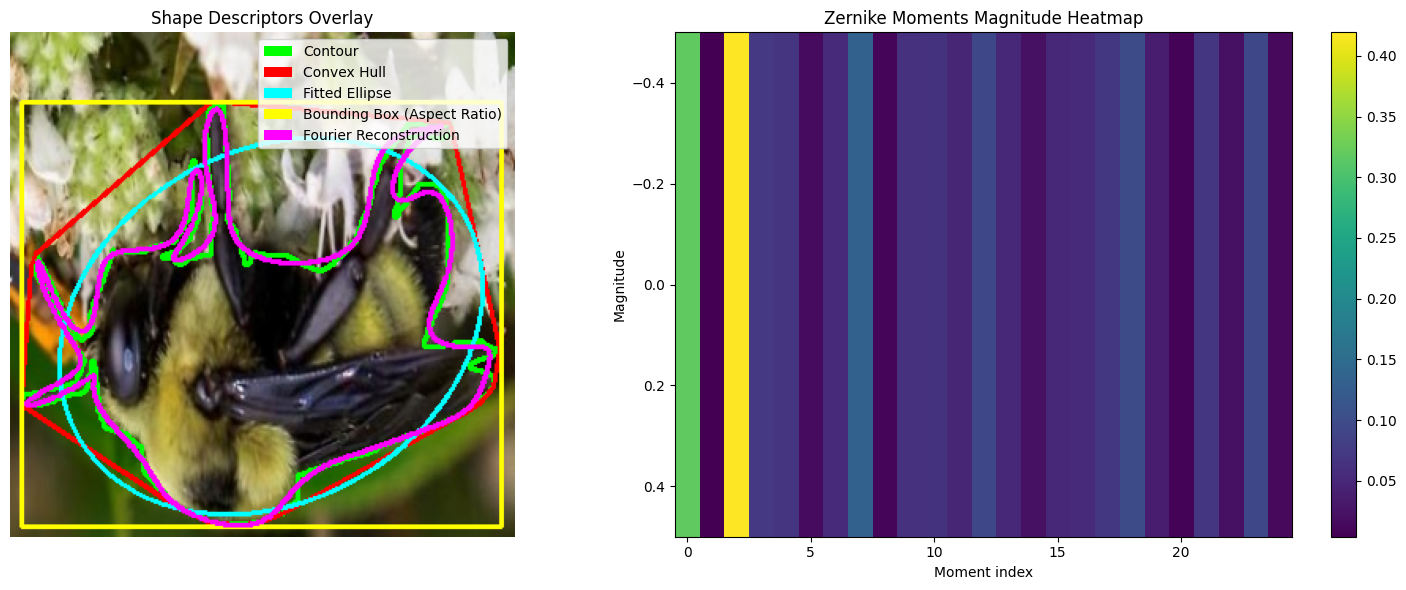

In [74]:
image, mask = train_dataset[90]
np_image = np.array(image)
np_image = np_image.transpose(1, 2, 0)
np_image = img_as_ubyte(np_image)
visualize_shape_descriptors(mask.numpy(), np_image, zernike_degree=8, fourier_harmonics=20)

### **Visual features** (Brightness, contrast, sharpness, colorfulness, brisque, niqe, piqe)

In [75]:
def show_cropped_image(image, mask):
    # --- 1. Ensure binary uint8 mask ---
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    if (image is not None) and (not isinstance(image, np.ndarray)):
        image = image.detach().cpu().numpy().transpose(1, 2, 0) # Transform tensor to numpy image
    img_cropped = np.zeros_like(image)
    img_cropped[mask==1] = image[mask==1]
    plt.imshow(img_cropped)

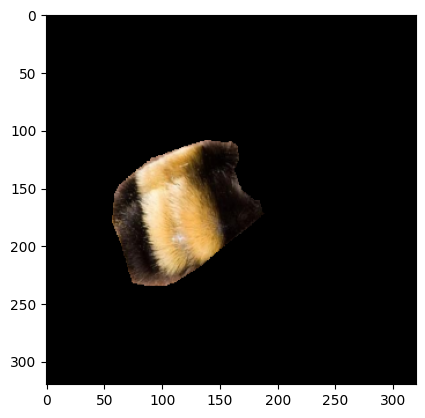

In [76]:
image, mask = train_dataset[8]
abdomen_mask = mask == 1
head_mask = mask == 2
thorax_mask = mask == 3
full_mask = mask > 0

show_cropped_image(image, abdomen_mask)

In [77]:
def extract_visual_features(image, mask):
    # --- 1. Ensure binary uint8 mask ---
    if not isinstance(mask, np.ndarray):
        mask = mask.numpy().astype(np.uint8)
    # Convert image to numpy
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    elif isinstance(image, Image.Image):
        image = np.array(image.convert('RGB'))
    img_cropped = np.zeros_like(image)
    img_cropped[mask==1] = image[mask==1]
    # plt.imshow(img_cropped)

    # --- Brightness ---
    brightness = np.mean(img_cropped)

    # --- Contrast (standard deviation of luminance) ---
    gray = rgb2gray(img_cropped)
    contrast = np.std(gray)

    # --- Sharpness (variance of Laplacian) ---
    gray_8u = (gray * 255).astype(np.uint8)
    lap_var = cv2.Laplacian(gray_8u, cv2.CV_64F).var()

    # --- Colorfulness (Hasler & Süsstrunk, 2003) ---
    (R, G, B) = cv2.split(img_cropped)
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, std_yb = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

    # --- Entropy (texture complexity) ---
    entropy = shannon_entropy(gray)

    # BRISQUE
    bri_obj = BRISQUE(url=False)
    brisque_score = bri_obj.score(img_cropped)

    # NIQE
    niqe_score = niqe(gray)

    # PIQE
    piqe_score, activityMask, noticeableArtifactMask, noiseMask = piqe(gray)

    # --- Aggregate descriptors ---
    descriptors = {
        "brightness": np.float32(brightness),
        "contrast": np.float32(contrast),
        "sharpness": np.float32(lap_var),
        "colorfulness": np.float32(colorfulness),
        "entropy": np.float32(entropy),
        "brisque": np.float32(brisque_score),
        "niqe": np.float32(niqe_score.item()),
        "piqe": np.float32(piqe_score)
    }
    return descriptors

In [78]:
extract_visual_features(image, abdomen_mask)

{'brightness': 0.04289442,
 'contrast': 0.16563955,
 'sharpness': 216.64804,
 'colorfulness': 0.093213424,
 'entropy': 1.8729261,
 'brisque': 85.76023,
 'niqe': 26.21164,
 'piqe': 43.773247}

In [79]:
extract_visual_features(image, head_mask)

{'brightness': 0.006009332,
 'contrast': 0.05001674,
 'sharpness': 355.02747,
 'colorfulness': 0.019701485,
 'entropy': 0.3580212,
 'brisque': 112.163925,
 'niqe': 26.799536,
 'piqe': 77.82725}

In [80]:
def extract_combined_features(image, mask): 
    # ---- Convert once ----
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy().transpose(1, 2, 0)
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy().astype(np.uint8)
    mask_u8 = mask.astype(np.uint8)
    image_f = (image - image.min()) / (image.max() - image.min() + 1e-8) # Linearly rescale to [0, 1] and avoid division by zero
    image_u8 = img_as_ubyte(image_f)

    combined_features = extract_shape_features(image_u8, mask_u8)
    vis_features = extract_visual_features(image_f, mask_u8)
    combined_features.update(vis_features)
    return combined_features

In [81]:
def extract_all_features(image, mask):
    abdomen_mask = mask == 1
    head_mask = mask == 2
    thorax_mask = mask == 3
    full_mask = mask > 0

    head_feats = extract_combined_features(image, head_mask)
    thorax_feats = extract_combined_features(image, thorax_mask)
    abdomen_feats = extract_combined_features(image, abdomen_mask)
    body_feats = extract_combined_features(image, full_mask)

    # Ratios
    area_sum = head_feats["area"] + thorax_feats["area"] + abdomen_feats["area"]
    ratios = {
        "head_to_thorax_area": head_feats["area"] / (thorax_feats["area"] + 1e-6),
        "thorax_to_abdomen_area": thorax_feats["area"] / (abdomen_feats["area"] + 1e-6),
        "head_to_total_area": head_feats["area"] / (area_sum + 1e-6),
        "thorax_to_total_area": thorax_feats["area"] / (area_sum + 1e-6),
        "abdomen_to_total_area": abdomen_feats["area"] / (area_sum + 1e-6),
    }

    record = {}
    record.update({f"head_{k}": v for k, v in head_feats.items()})
    record.update({f"thorax_{k}": v for k, v in thorax_feats.items()})
    record.update({f"abdomen_{k}": v for k, v in abdomen_feats.items()})
    record.update({f"full_{k}": v for k, v in body_feats.items()})
    record.update(ratios)
    return record

In [82]:
extract_combined_features(image, head_mask)

{'area': 2037.0,
 'perimeter': 449.75946,
 'aspect_ratio': 1.5604919,
 'extent': 0.1708033,
 'solidity': 0.32073689,
 'eccentricity': 0.76768816,
 'orientation': 0.19300832,
 'circularity': 0.12654363,
 'elongation': 0.35917643,
 'compactness': 7.9024124,
 'sift_ds1': 17.947369,
 'sift_ds2': 17.552631,
 'sift_ds3': 18.842106,
 'sift_ds4': 29.18421,
 'sift_ds5': 26.447369,
 'sift_ds6': 21.421053,
 'sift_ds7': 15.263158,
 'sift_ds8': 6.8157897,
 'sift_ds9': 52.210526,
 'sift_ds10': 26.657894,
 'sift_ds11': 10.552631,
 'sift_ds12': 26.447369,
 'sift_ds13': 39.605263,
 'sift_ds14': 20.236841,
 'sift_ds15': 12.605263,
 'sift_ds16': 17.0,
 'sift_ds17': 82.1579,
 'sift_ds18': 31.81579,
 'sift_ds19': 6.631579,
 'sift_ds20': 10.236842,
 'sift_ds21': 12.210526,
 'sift_ds22': 11.263158,
 'sift_ds23': 11.131579,
 'sift_ds24': 41.973682,
 'sift_ds25': 38.973682,
 'sift_ds26': 25.657894,
 'sift_ds27': 7.3157897,
 'sift_ds28': 9.026316,
 'sift_ds29': 6.8421054,
 'sift_ds30': 12.0,
 'sift_ds31': 11.13

In [83]:
d = extract_all_features(image, mask)
print("Total features for each image:", len(d.keys()))

Total features for each image: 937


As discussed, each part mask has 225 shape descriptors and 8 visual descriptors. We have five values for inter-part ratios: head_to_thorax, thorax_to_abdomen, head_to_total, thorax_to_total and abdomen_to_total. Therefore, total number of descriptors for all parts (head, thorax, abdomen, fullbody) = (225+8)*4 + 5 = 932 + 5 = 937